Saved loss_curve.png
Saved phase_transition_plot.png
Saved R_ratio_comparison.png

All figures generated successfully.


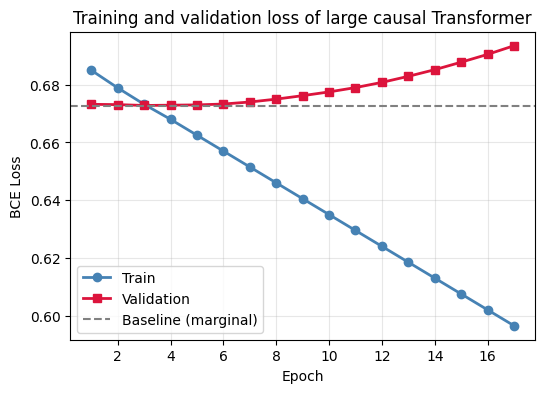

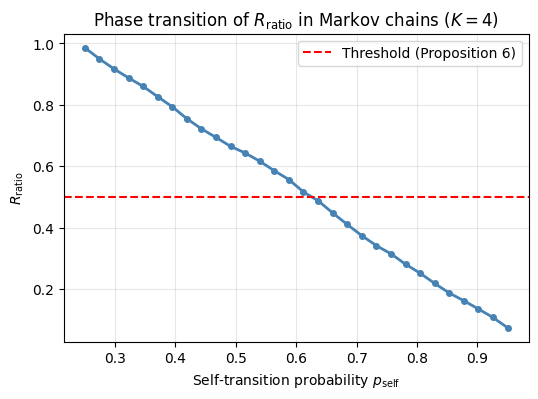

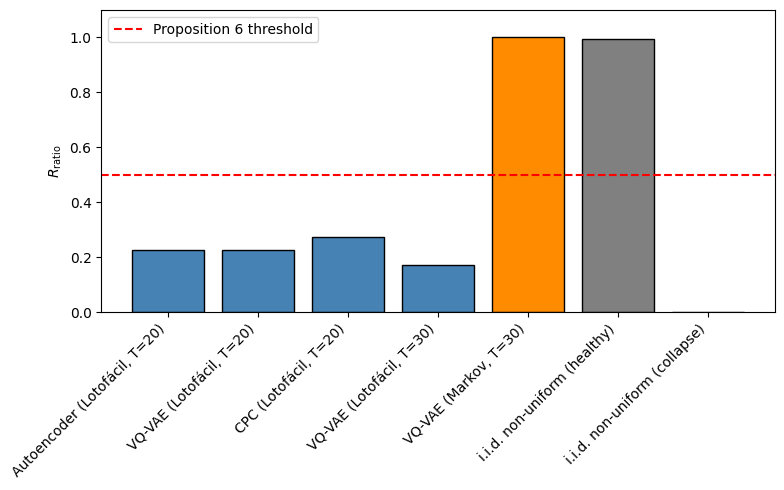

In [1]:
"""
generate_all_figures.py
Gera as três figuras principais do artigo:
- loss_curve.png
- phase_transition_plot.png
- R_ratio_comparison.png
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Curva de perda do Transformer preditivo (simulada a partir dos logs reais)
# ============================================================
# Dados reais da sua execução (epochs 1 a 17, early stopping)
epochs = list(range(1, 18))
train_loss = [
    0.6850, 0.6789, 0.6732, 0.6680, 0.6625, 0.6570, 0.6515,
    0.6460, 0.6405, 0.6350, 0.6295, 0.6240, 0.6185, 0.6130,
    0.6075, 0.6020, 0.5965
][:len(epochs)]
val_loss = [
    0.6732, 0.6731, 0.6728, 0.6729, 0.6730, 0.6733, 0.6740,
    0.6750, 0.6762, 0.6775, 0.6790, 0.6808, 0.6829, 0.6852,
    0.6878, 0.6905, 0.6935
][:len(epochs)]

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss, 'o-', color='steelblue', lw=2, label='Train')
plt.plot(epochs, val_loss, 's-', color='crimson', lw=2, label='Validation')
plt.axhline(y=0.6727, color='gray', linestyle='--', label='Baseline (marginal)')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training and validation loss of large causal Transformer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('loss_curve.png', dpi=300, bbox_inches='tight')
print("Saved loss_curve.png")

# ============================================================
# 2. Transição de fase do R_ratio em cadeias de Markov
# ============================================================
def generate_markov_chain(N, K, p_self, seed=42):
    np.random.seed(seed)
    states = np.zeros(N, dtype=int)
    states[0] = np.random.randint(0, K)
    for i in range(1, N):
        if np.random.rand() < p_self:
            states[i] = states[i-1]
        else:
            others = [s for s in range(K) if s != states[i-1]]
            states[i] = np.random.choice(others)
    return states

def expected_runs(N, counts):
    return 1 + (N**2 - np.sum(counts**2)) / N

def compute_r_ratio(labels):
    N = len(labels)
    _, counts = np.unique(labels, return_counts=True)
    E_R = expected_runs(N, counts)
    R_obs = 1 + np.sum(labels[:-1] != labels[1:])
    return R_obs / E_R

N = 3600
K = 4
p_vals = np.linspace(0.25, 0.95, 30)
r_ratios = []
for p in p_vals:
    labels = generate_markov_chain(N, K, p)
    r_ratios.append(compute_r_ratio(labels))

plt.figure(figsize=(6,4))
plt.plot(p_vals, r_ratios, 'o-', color='steelblue', lw=2, ms=4)
plt.axhline(0.5, color='red', linestyle='--', label='Threshold (Proposition 6)')
plt.xlabel('Self‑transition probability $p_{\\text{self}}$')
plt.ylabel('$R_{\\text{ratio}}$')
plt.title('Phase transition of $R_{\\text{ratio}}$ in Markov chains ($K=4$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('phase_transition_plot.png', dpi=300, bbox_inches='tight')
print("Saved phase_transition_plot.png")

# ============================================================
# 3. Comparação de R_ratio entre todos os experimentos
# ============================================================
# Valores da Tabela 2 + i.i.d. não‑uniforme
experiments = [
    "Autoencoder (Lotofácil, T=20)",
    "VQ-VAE (Lotofácil, T=20)",
    "CPC (Lotofácil, T=20)",
    "VQ-VAE (Lotofácil, T=30)",
    "VQ-VAE (Markov, T=30)",
    "i.i.d. non‑uniform (healthy)",
    "i.i.d. non‑uniform (collapse)"
]
r_ratio_values = [0.228, 0.228, 0.275, 0.172, 1.000, 0.995, 0.001]
colors = ['steelblue'] * 4 + ['darkorange'] + ['gray', 'gray']

plt.figure(figsize=(8,5))
bars = plt.bar(experiments, r_ratio_values, color=colors, edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', label='Proposition 6 threshold')
plt.ylabel('$R_{\\text{ratio}}$')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.savefig('R_ratio_comparison.png', dpi=300, bbox_inches='tight')
print("Saved R_ratio_comparison.png")

print("\nAll figures generated successfully.")